# Experiment 4.1 — Causal positional information for RSNN

Question: does explicit causal elapsed-time / absolute-slot information close the gap between Exp4.0 RSNN and Fixed250+Linear?

Only two Exp4.0 anchor configurations are used: `H=64, tau=1000 ms` and `H=128, tau=250 ms`. The no-position controls are reused from Exp4.0; only scalar and one-hot position cases are newly trained.

In [1]:
from pathlib import Path
import json
import sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'snn').is_dir() and (candidate / 'notebooks').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate writingRing repository root')

repo_root = find_repo_root()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
from scripts import experiment_4_0_fixed250_temporal_snn as exp40
from scripts import experiment_4_1_causal_position_rsnn as exp41

root = exp41.results_dir(repo_root)
runs_path = root / 'runs.csv'
summary_path = root / 'summary.csv'
paired_path = root / 'paired_position_effects.csv'
eval_dir = root / 'evaluations'
eval_count = len(list(eval_dir.glob('*.json'))) if eval_dir.exists() else 0
ready = runs_path.exists() and summary_path.exists() and paired_path.exists()
print('Artifact root:', root)
print(f'New position-aware evaluations: {eval_count}/{exp41.EXPECTED_NEW_RUNS}')
print('Finalized:', ready)
if ready:
    runs = pd.read_csv(runs_path)
    summary = pd.read_csv(summary_path)
    paired = pd.read_csv(paired_path)
    baseline = json.loads((exp40.results_dir(repo_root) / 'baseline' / 'fixed250_linear.json').read_text())
    display(summary)
    display(paired)
    print('Linear reference test BA:', baseline['metrics']['test']['balanced_accuracy'])
else:
    runs = summary = paired = baseline = None
    print('Run: bash scripts/bash_script/SNN_Bash/submit_exp_4_1_cpu.bash')

Artifact root: /home/zhaolongwei_umass_edu/projects/writingRing/notebooks/artifacts/experiment_4_1_causal_position_rsnn/causal_position_v1
New position-aware evaluations: 20/20
Finalized: True


,hidden_width,tau_mem_ms,position_encoding,valid_count_balanced_accuracy_mean,valid_count_balanced_accuracy_std,valid_count_macro_f1_mean,valid_count_macro_f1_std,full_count_balanced_accuracy_mean,full_count_balanced_accuracy_std,tail_spike_fraction_mean,tail_spike_fraction_std
0,64,1000.0,none,0.340511,0.030960,0.339472,0.041429,0.191307,0.046039,0.549611,0.096051
1,64,1000.0,onehot,0.366231,0.056538,0.353188,0.054445,0.240336,0.093120,0.565671,0.081690
2,64,1000.0,scalar,0.315863,0.050880,0.296738,0.055113,0.169113,0.037914,0.593020,0.074718
3,128,250.0,none,0.349288,0.045759,0.341719,0.053809,0.267217,0.035938,0.634499,0.076757
4,128,250.0,onehot,0.376301,0.047790,0.361944,0.040720,0.325802,0.031657,0.455466,0.139996
5,128,250.0,scalar,0.325937,0.028315,0.308267,0.026779,0.262908,0.049557,0.463276,0.183199


,hidden_width,tau_mem_ms,seed,none,onehot,scalar,scalar_minus_none,onehot_minus_none
0,64,1000.0,11,0.345097,0.287050,0.345346,0.000248,-0.058047
1,64,1000.0,23,0.296946,0.364046,0.258272,-0.038675,0.067100
2,64,1000.0,37,0.330613,0.438072,0.280703,-0.049910,0.107459
3,64,1000.0,53,0.382595,0.345447,0.309212,-0.073384,-0.037148
4,64,1000.0,71,0.347305,0.396538,0.385782,0.038477,0.049233
5,128,250.0,11,0.332723,0.356134,0.358046,0.025323,0.023411
6,128,250.0,23,0.375653,0.360514,0.308454,-0.067199,-0.015138
7,128,250.0,37,0.277235,0.315042,0.331156,0.053921,0.037807
8,128,250.0,53,0.368659,0.425840,0.344703,-0.023957,0.057181
9,128,250.0,71,0.392172,0.423975,0.287325,-0.104847,0.031803


Linear reference test BA: 0.5491064491064491


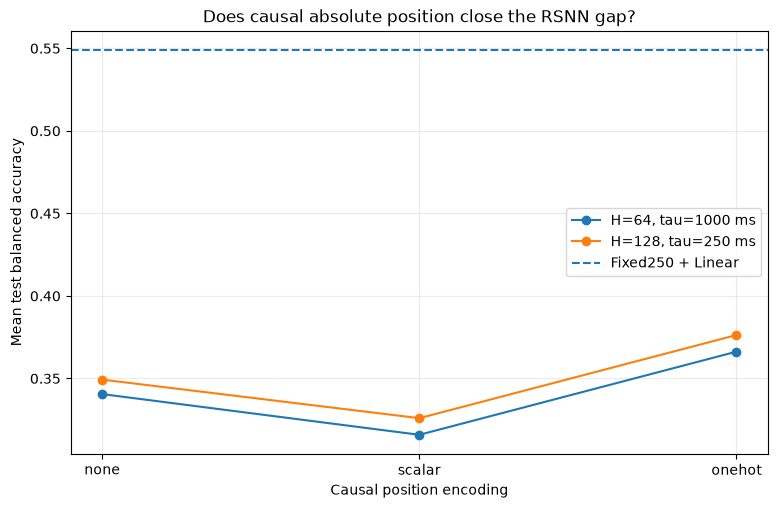

In [2]:
if not ready:
    print('Skipped: position-effect plot requires finalized artifacts.')
else:
    test = runs[runs['split'] == 'test'].copy()
    view = (test.groupby(['hidden_width', 'tau_mem_ms', 'position_encoding'], as_index=False)
                ['valid_count_balanced_accuracy'].mean())
    fig, ax = plt.subplots(figsize=(9, 5.5))
    for (width, tau), frame in view.groupby(['hidden_width', 'tau_mem_ms']):
        order = ['none', 'scalar', 'onehot']
        frame = frame.set_index('position_encoding').reindex(order).reset_index()
        ax.plot(frame['position_encoding'], frame['valid_count_balanced_accuracy'], marker='o', label=f'H={width}, tau={int(tau)} ms')
    ax.axhline(baseline['metrics']['test']['balanced_accuracy'], linestyle='--', label='Fixed250 + Linear')
    ax.set_ylabel('Mean test balanced accuracy')
    ax.set_xlabel('Causal position encoding')
    ax.set_title('Does causal absolute position close the RSNN gap?')
    ax.legend()
    ax.grid(True, alpha=0.25)
    plt.show()

In [3]:
if not ready:
    print('Skipped: paired deltas require finalized artifacts.')
else:
    delta_cols = ['scalar_minus_none', 'onehot_minus_none']
    display(paired.groupby(['hidden_width', 'tau_mem_ms'])[delta_cols].agg(['mean', 'std']))
    tail = (runs[runs['split'] == 'test']
            .groupby(['hidden_width', 'tau_mem_ms', 'position_encoding'], as_index=False)
            ['tail_spike_fraction'].mean())
    display(tail)

scalar_minus_none           onehot_minus_none  \
                                     mean       std              mean   
hidden_width tau_mem_ms                                                 
64           1000.0             -0.024649  0.044200          0.025720   
128          250.0              -0.023352  0.065009          0.027013   

                                   
                              std  
hidden_width tau_mem_ms            
64           1000.0      0.070562  
128          250.0       0.026642

,hidden_width,tau_mem_ms,position_encoding,tail_spike_fraction
0,64,1000.0,none,0.549611
1,64,1000.0,onehot,0.565671
2,64,1000.0,scalar,0.593020
3,128,250.0,none,0.634499
4,128,250.0,onehot,0.455466
5,128,250.0,scalar,0.463276
